# Notebook 1: Data Acquisition & Exploratory Data Analysis
## HIV-1 Subtype Classification Using the pol Gene

 We download sequence data FASTA files directly from **Los Alamos National Laboratory (LANL)** via their web interface; https://www.hiv.lanl.gov/components/sequence/HIV/search/search.html.
  This is because LANL has no public API that could allow use of programmatic tools like (`Entrez`) from Biopython's for automatic downloading.

  We then clean it to create a final dataset for our model building


## Step 1: Import required Libraries

In [8]:
!pip -q install biopython # for sequence manupulation tools

import os # Import the os module for operating system dependent functionality
import json # for working with JSON data
import requests # for making HTTP requests that enables direct access of websites
import pandas as pd # for data manipulation and analysis
import numpy as np # for numerical computing
import matplotlib.pyplot as plt # for creating static, interactive, and animated visualizations
import seaborn as sns # for statistical data visualization
from Bio import SeqIO # for parsing sequence files

## Step 2: Set up project directories

In [9]:
# Mount Drive and setup project folder
from google.colab import drive # Import drive from google.colab to mount Google Drive
drive.mount('/content/drive') # Mount Google Drive to access files

projectdir = '/content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final' # Base project directory path
rawdata = os.path.join(projectdir, 'data', 'raw') # path for raw data
processed_data = os.path.join(projectdir, 'data', 'processed') # path for processed data
reports = os.path.join(projectdir, 'reports', 'figures') # path for figures and reports

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## Step 3: Generate Kameris Accession List
To ensure replication of the the Solis-Reyes et al. (2018) dataset, we will download their experiment metadata and extract the exact **9,270** Accession IDs they used for the `hiv1/lanl-pol` dataset. We shall create a text file that we can upload directly to the LANL search interface to fetch the exact dataset!

In [10]:

# Download json file with sequence accesssion numbers from the kameris github repository
for d in [rawdata, processed_data, reports]: # Iterate through the defined directory paths
    os.makedirs(d, exist_ok=True) # Create directories if they don't already exist

print('Downloading Kameris metadata...') # Print a status message
metadata_url = ('https://raw.githubusercontent.com/stephensolis/' # Define the URL for the metadata file
                'kameris-experiments/master/metadata/hiv1-lanl-pol.json')
response = requests.get(metadata_url) # Send an HTTP GET request to the metadata URL
response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
kameris_meta = pd.DataFrame(json.loads(response.text)) # Parse the JSON response and convert it to a pandas DataFrame

# Extract ALL accessions used by Kameris for the pol dataset (9,270 total)
accessions = kameris_meta['id'].tolist() # Extract the 'id' column and convert it to a list of accessions

samplelist = os.path.join(rawdata, 'kameris_pol_accessions.txt') # Define the path for saving the accession list
with open(samplelist, 'w') as f: # Open the file in write mode
    f.write('\n'.join(accessions)) # Write each accession to a new line in the file

print(f'\nSUCCESS! Saved exactly {len(accessions)} accessions to {samplelist}') # Print a success message with the count of accessions
print('You can now download this text file from your Google Drive and upload it to LANL.') # Instruct the user on the next step


SUCCESS! Saved exactly 9270 accessions to /content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final/data/raw/kameris_pol_accessions.txt
You can now download this text file from your Google Drive and upload it to LANL.


## Step 4: Download FASTA from LANL using Exact Accessions

1. Download the `kameris_pol_accessions.txt` file from your Google Drive (in the `data/raw/` folder).
2. Go to the [LANL HIV Search Interface](https://www.hiv.lanl.gov/components/sequence/HIV/search/search.html)
3. Set the following parameters:
   * **Upload accession file:** Click *Choose File* and upload the `kameris_pol_accessions.txt` file.
   * **Genomic region:** Select `Pol CDS` *(this guarantees we only get the pol gene region for these sequences!)*
   * *(You do not need to select Virus, Subtype, or Year, because the accession file explicitly requests the exact 9,270 sequences we need)*
4. Click **Search** at the bottom of the page.
5. On the results page, click the **Download Sequences** button.
6. In the download options:
   * **Format:** `Fasta`
   * **Sequence type:** `Nucleotides`
   * Click **Download**
7. Rename the downloaded file to `lanl_pol_sequences.fasta`.
8. Upload this file to your Google Drive under `hiv-subtype-classifier/data/raw/`.

## Step 5: Parse the LANL FASTA File
LANL FASTA headers usually contain metadata separated by dots (e.g., `Subtype.Country.Year.Name.Accession`). We will inspect our .txt file to confirm this and parse it to extract the Subtype and Accession ID.

In [11]:
import os

# Inspect the raw FASTA file content before parsing
fasta_files = os.path.join(rawdata, 'lanl_pol_sequences.fasta') # Define fasta_files
with open(fasta_files, 'r') as f: # Open the FASTA file in read mode
    raw_fasta_preview = f.read(1000) # Read the first 1000 characters
print('--- Raw FASTA Preview ---')
print(raw_fasta_preview)

--- Raw FASTA Preview ---
>B.FR.1983.IIIB_LAI.A04321
TTTTT-TA---GGGAA-GATCTGGCCTTCC---T---A---CAAGGGA--
--AGGC---CA---GGG-AATTTTCTTCAG------AG-----C----AG
A------------------------------------------CC---AG
AGCC----AACAGCCCCA--------------------------------
----------------------CC---A------------GA-A--GAG-
-A----GCT-------TC---AG-GTCT------GG------GGT--AG-
-----AGACA---A------CA----------------------------
------ACTCC---------C------------T------C---T-----
---C---A---G------A---A------G------------CAG-----
G------AG---CCG-----------------------------------
-------------ATAG-A------------CA---A------G------
GAA---CTG------------------------TAT------CC---TTT
---A-ACTTCCCTCAGATCACTCTTTGGCAACGACCCCTCGTCACAATAA
AGATA-GGGGGGCAACTAAAGGAAGCTCTATT-AGATACAGGAGCAGATG
ATACAGTATT------A-GAAGAA------A---TGAGTTTG--CCAGGA
A---GATGGAAACCAAAAAT--GATAGGGGGAATTGGAGGTTTTATCAAA
GTAAGACAGT-ATGATCAGATA--CTCATAGAAATCTGTGGACATAAA-G
CTAT-AGGTACAG---TATTAGTAGGACC-TACACCTGTCAACA---TAA
TTGGAAGAAATCTGTTGACTCAGATTGGT

## FASTA Sequence Parsing
Reads and extracts genomic sequences from the LANL FASTA database.

In [12]:
# Parse the LANL FASTA File
fasta_files = os.path.join(rawdata, 'lanl_pol_sequences.fasta') # Define the full path to the FASTA file
if not os.path.exists(fasta_files): # Check if the FASTA file exists
    raise FileNotFoundError(f'Please download the FASTA file from LANL and upload it to: {fasta_files}') # Raise an error if the file is not found


records = [] # Initialize an empty list to store parsed sequence records
for record in SeqIO.parse(fasta_files, 'fasta'): # Iterate through each sequence record in the FASTA file
    # LANL headers format: Subtype.Country.Year.Name.Accession
    parts = record.id.split('.') # Split the record ID by '.' to extract metadata parts into a list

    # Fallback for sequence header format with a different header format
    subtype = parts[0] if len(parts) > 0 else 'Unknown' # Extract subtype, defaulting to 'Unknown' if not found
    accession = parts[-1] if len(parts) > 4 else record.id # Extract accession, defaulting to the full ID if not enough parts
    country = parts[1] if len(parts) > 1 else 'Unknown' # Extract country, defaulting to 'Unknown' if not found
    year = parts[2] if len(parts) > 2 else 'Unknown' # Extract year, defaulting to 'Unknown' if not found

    records.append({ # Append a dictionary of extracted data to the records list
        'id': accession, # Accession ID
        'subtype': subtype, # HIV subtype
        'country': country, # Country of origin
        'year': year, # Year of collection
        'sequence': str(record.seq).upper(), # Nucleotide sequence, converted to uppercase
        'seq_length': len(record.seq) # Length of the sequence
    })

df = pd.DataFrame(records) # Convert the list of records into a pandas DataFrame
print(f'Total sequences parsed: {len(df)} out of 9,270') # Print the total number of sequences parsed
print('\nFirst rows of the dataframe')
display(df.head())


Total sequences parsed: 9264 out of 9,270

First rows of the dataframe


,id,subtype,country,year,sequence,seq_length
0,A04321,B,FR,1983,TTTTT-TA---GGGAA-GATCTGGCCTTCC---T---A---CAAGG...,4259
1,A07867,B,FR,1983,TTTTT-TA---GGGAA-GATCTGGCCTTCC---T---A---CAAGG...,4259
2,AB023804,C,IN,1993,TTTTT-TA---GGGAA-AATTTGGCCTTCC---C---A---CAAGG...,4259
3,AB049811,02_AG,GH,1997,TTTTT-TA---GGGAA-AATTTGGCCTTCC---A---G---CAAAG...,4259
4,AB052867,02A1,GH,1997,TTTTT-TA---GGGAA-AATTTGGCCTTCC---A---A---CAAGG...,4259


### Check sequence length distribution


--- Sequence Length distribution---


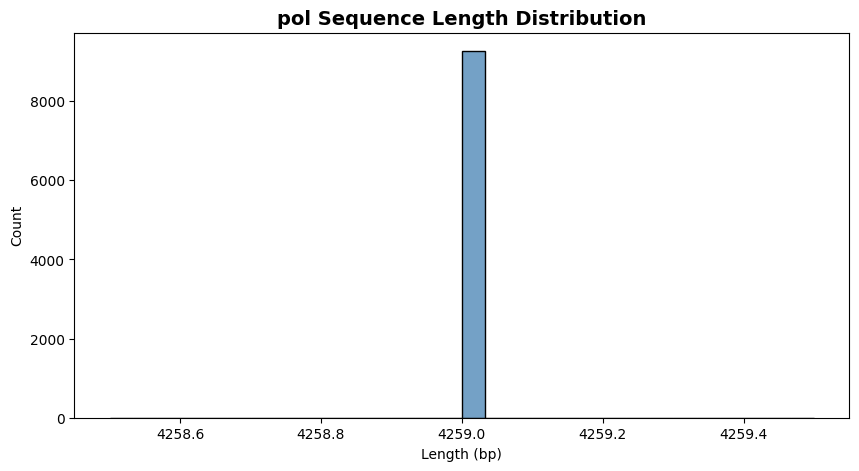

--- sequence Length Statistics---
count    9264.0
mean     4259.0
std         0.0
min      4259.0
25%      4259.0
50%      4259.0
75%      4259.0
max      4259.0
Name: seq_length, dtype: float64


In [13]:
print('\n--- Sequence Length distribution---')
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['seq_length'], bins=30, kde=False, ax=ax, color='steelblue')
ax.set_title('pol Sequence Length Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Length (bp)')

# Check if reports directory exists before saving
if 'reports' in globals() and os.path.exists(os.path.dirname(reports)):
    plt.savefig(f'{reports}/sequence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print("--- sequence Length Statistics---")
top_subtypes = df['subtype'].value_counts().nlargest(10).index
print(df['seq_length'].describe())

### Check missing sequences

In [14]:
# Compare the original Kameris list with our parsed DataFrame
missing_accessions = set(accessions) - set(df['id'].tolist())

print(f'Count of missing accessions: {len(missing_accessions)}')
if len(missing_accessions) > 0:
    print('The following accessions were not found in the LANL Pol download:')
    print(list(missing_accessions))

Count of missing accessions: 6
The following accessions were not found in the LANL Pol download:
['JX976731', 'FJ900269', 'AF003888', 'AF003887', 'GQ371946', 'FJ771007']


## Quality Control
Analyzes sequences with missing metadata or accession numbers.

In [15]:
# Pull out metadata for missing accession numbers to be better understand them
missing_list = ['AF003888', 'FJ771007', 'AF003887', 'GQ371946', 'FJ900269', 'JX976731']
missing_info = kameris_meta[kameris_meta['id'].isin(missing_list)]
display(missing_info[['id', 'subtype', 'start_position', 'end_position', 'length']])

,id,subtype,start_position,end_position,length
248,AF003887,B,2358.0,5096.0,2739
249,AF003888,B,2337.0,5075.0,2739
5148,JX976731,C,1533.0,4531.0,2999
9121,GQ371946,B,NaN,NaN,3006
9194,FJ900269,F1,NaN,NaN,3018
9195,FJ771007,F1,NaN,NaN,3042


### Reason for Missing Sequences
As shown above, sequences like `GQ371946`,`FJ900269` and `FJ771007` have **NaN** for their start and end positions. Because we filtered the LANL search by **'Pol CDS'**, the database only returns records where that specific coding sequence is explicitly annotated. Since these 3 lack those precise coordinates they were automatically excluded from the download.

Additionally, our downloaded dataset has a median length of **4,259 bp** while the rest of the missing sequences are significantly shorter (e.g., `AF003887` is only **2,739 bp**). The LANL 'Pol CDS' filter specifically targets sequences with a complete, annotated Coding Sequence. Since these 3 accessions represent partial fragments rather than the full gene, they do not carry the specific 'CDS' metadata tag required by the LANL search engine, causing them to be skipped during the batch download.

## Step 5: Map Subtypes and clean data set
The kameris dataset included all subtypes their Recombinants (CRFs) and minor subtypes (F, G, O, etc.). Since we are specifically building a **4-class model (A, B, C, D)**, in this step we map and filter sequences for subtypes of interest and drop the rest.

In [16]:
# Check all subtypes in the dataset and their counts
subtype_counts = df['subtype'].value_counts().reset_index()
subtype_counts.columns = ['Subtype', 'Count']
display(subtype_counts)

,Subtype,Count
0,B,2922
1,C,2311
2,01_AE,1455
3,07_BC,325
4,A1,277
...,...,...
221,UO,1
222,A1GH,1
223,BCG,1
224,14F1,1


## Subtype Classification Mapping
Maps hyper-specific LANL subtypes into the four broader target classes (A, B, C, D).

In [17]:
# Map specific subtypes to broader classes
subtype_map = {'A1': 'A', 'A': 'A', 'B': 'B', 'C': 'C', 'D': 'D'}

def map_subtype(st):
    return subtype_map.get(st.upper(), None)

df['subtype_class'] = df['subtype'].apply(map_subtype)
df = df[df['subtype_class'].notna()].copy()

print('=== Data Cleaning ===')
print(f'Target pure subtypes (A, B, C, D) only: {len(df)} sequences')

# Remove sequences with >5% ambiguous bases  (letters other than `A, C, G or T`)
# Ignore gaps ('-') when calculating percentage of ambiguous bases
df['pct_amb'] = df['sequence'].apply(lambda s: sum(c not in 'ACGT' for c in s.replace('-', '')) / len(s.replace('-', '')) if len(s.replace('-', '')) > 0 else 1.0)
df = df[df['pct_amb'] <= 0.05].copy()
print(f'After removing >5% ambiguous bases: {len(df)}')

# Remove duplicates
df = df.drop_duplicates(subset='sequence').copy()
print(f'After removing exact duplicates: {len(df)}')

# Final Dataset
print(f'\nFinal modeling dataset: {len(df)} sequences')
print(df['subtype_class'].value_counts().sort_index())

=== Data Cleaning ===
Target pure subtypes (A, B, C, D) only: 5588 sequences
After removing >5% ambiguous bases: 5588
After removing exact duplicates: 5564

Final modeling dataset: 5564 sequences
subtype_class
A     278
B    2908
C    2303
D      75
Name: count, dtype: int64


## Step 6: Check missing values

In [18]:
# Check for missing values per column in the cleaned dataset
print('--- Missing Values Per Column ---')
display(df.isnull().sum())

--- Missing Values Per Column ---


,0
id,0
subtype,0
country,0
year,0
sequence,0
seq_length,0
subtype_class,0
pct_amb,0


## Step 7: Check subtype distributions

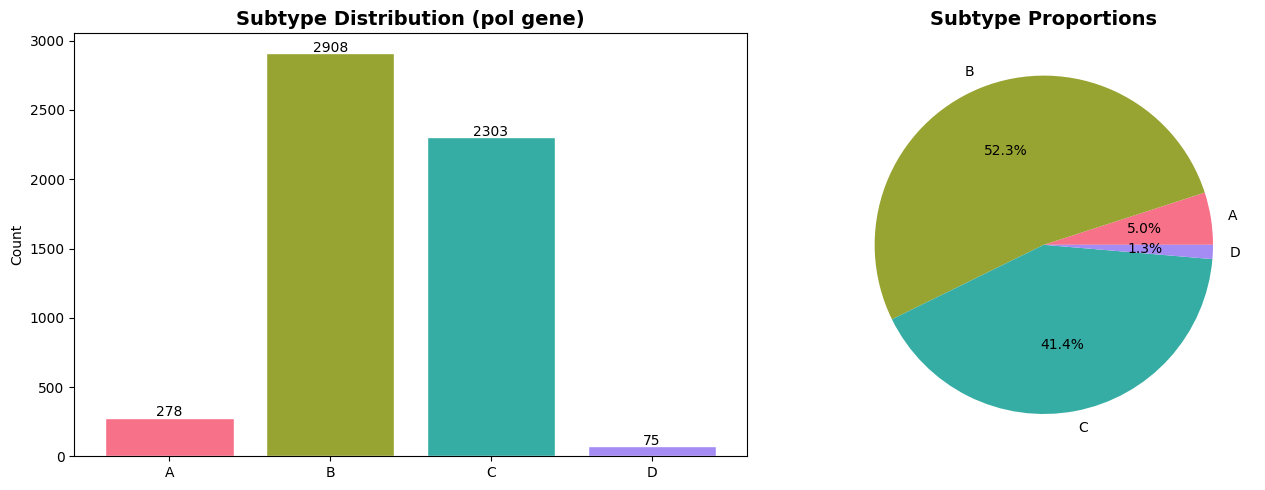

In [19]:
# 5a. Subtype distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['subtype_class'].value_counts().sort_index()
colors = sns.color_palette('husl', len(counts))
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Subtype Distribution (pol gene)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+10, str(v), ha='center')
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Subtype Proportions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{reports}/subtype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Save Processed Data

In [20]:
save_cols = ['id', 'sequence', 'subtype_class', 'seq_length', 'country', 'year']
df[save_cols].to_pickle(os.path.join(processed_data, 'sequences_cleaned.pkl'))
meta_cols = [c for c in df.columns if c != 'sequence']
df[meta_cols].to_csv(os.path.join(processed_data, 'metadata.csv'), index=False)
print(f'Saved {len(df)} modeling sequences to {processed_data}')
print(f'Classes: {sorted(df["subtype_class"].unique())}')
print('--- Ready for Notebook 02: Preprocessing ---')

Saved 5564 modeling sequences to /content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final/data/processed
Classes: ['A', 'B', 'C', 'D']
--- Ready for Notebook 02: Preprocessing ---
